# Simple-Inject (SI) Baseline & Inception Uplift Analysis

Reproduces blog claims about the simple-inject baseline and its uplift vs M5 inception attack.

**Data**: `evaluation/eval_deepseek_judge/{simple_inject,max_iterations_5}/{think,instruct}/<Model>/<Model>_safety_judge.pickle`

**Claims under test**
- F1: SI mean compliance ~24.4%, range 5.9–45.9%
- F2: Instruct > think on SI within model families
- F5: M5 vs SI median uplift +65.75 pp, all paired uplifts >50 pp
- F6: Kimi most susceptible; GLM-4.6 think most resistant on SI
- F4: Late refusals track compliance

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/home/md2292/inception-eval')
EVAL_ROOT = ROOT / 'evaluation' / 'eval_deepseek_judge'
SI_ROOT = EVAL_ROOT / 'simple_inject'
M5_ROOT = EVAL_ROOT / 'max_iterations_5'

pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 2. Load SI and M5 pickles

In [2]:
def discover(root):
    """Returns dict: {model_name: {'family': 'think'|'instruct', 'path': Path}}"""
    out = {}
    for fam in ('think', 'instruct'):
        fam_dir = root / fam
        if not fam_dir.exists():
            continue
        for model_dir in sorted(fam_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            pkl = model_dir / f'{model_dir.name}_safety_judge.pickle'
            if pkl.exists():
                out[model_dir.name] = {'family': fam, 'path': pkl}
    return out

si_models = discover(SI_ROOT)
m5_models = discover(M5_ROOT)
print(f'SI models: {len(si_models)} | M5 models: {len(m5_models)}')
print('SI:', sorted(si_models.keys()))
print('M5:', sorted(m5_models.keys()))

SI models: 9 | M5 models: 8
SI: ['DeepSeek-R1-0528', 'DeepSeek-V3.2', 'GLM-4.6', 'Kimi-K2-Instruct-0905', 'Kimi-K2-Thinking', 'Qwen3-235B-A22B-Instruct-2507', 'Qwen3-235B-A22B-Thinking-2507', 'Qwen3-Next-80B-A3B-Instruct', 'Qwen3-Next-80B-A3B-Thinking']
M5: ['DeepSeek-R1-0528', 'DeepSeek-V3.2', 'GLM-4.6', 'GPT-OSS-120B', 'Kimi-K2-Instruct-0905', 'Qwen3-235B-A22B-Instruct-2507', 'Qwen3-235B-A22B-Thinking-2507', 'Qwen3-Next-80B-A3B-Instruct']


In [3]:
def load_eval(path):
    df = pd.read_pickle(path)
    return df

si_dfs = {m: load_eval(info['path']) for m, info in si_models.items()}
m5_dfs = {m: load_eval(info['path']) for m, info in m5_models.items()}

# Sanity
sample = next(iter(si_dfs.values()))
print('SI shape (sample):', sample.shape)
print('SI columns:', list(sample.columns))

SI shape (sample): (800, 32)
SI columns: ['answer', 'question', 'choices', 'category', 'example', 'situation', 'inquiry', 'prompt', 'response', 'injection_prefix', 'reasoning_traces', 'response_eval', 'error', 'retries', 'finish_reason', 'raw_response', 'analysis', 'agent_class', 'agent_grade', 'delivery_method', 'exposure_environment', 'severity_level', 'fatalities', 'complied', 'late_refusal', 'specificity', 'convincingness', 'truncated', 'threat', 'contagiousness', 'route', 'scale']


## 3. Compute compliance metrics

In [4]:
def compliance_rate(df):
    s = pd.to_numeric(df['complied'], errors='coerce')
    return float(s.mean()) * 100

def late_refusal_rate(df):
    if 'late_refusal' not in df.columns:
        return np.nan
    s = pd.to_numeric(df['late_refusal'], errors='coerce')
    return float(s.mean()) * 100

def by_category(df, cat):
    sub = df[df['category'].astype(str).str.lower().str.contains(cat)]
    if len(sub) == 0:
        return np.nan
    return compliance_rate(sub)

rows = []
for m, info in si_models.items():
    df = si_dfs[m]
    rows.append({
        'model': m,
        'family': info['family'],
        'si_n': len(df),
        'si_compliance': compliance_rate(df),
        'si_late_refusal': late_refusal_rate(df),
        'si_bio': by_category(df, 'bio'),
        'si_chem': by_category(df, 'chem'),
    })
si_summary = pd.DataFrame(rows).sort_values('si_compliance', ascending=False).reset_index(drop=True)
si_summary

,model,family,si_n,si_compliance,si_late_refusal,si_bio,si_chem
0,Kimi-K2-Instruct-0905,instruct,800,45.875,5.375,49.000,42.750
1,DeepSeek-V3.2,instruct,800,41.625,6.750,48.000,35.250
2,DeepSeek-R1-0528,think,800,32.250,8.750,34.500,30.000
3,Qwen3-235B-A22B-Instruct-2507,instruct,800,28.875,8.625,30.250,27.500
4,Kimi-K2-Thinking,think,800,26.375,2.750,24.000,28.750
5,Qwen3-235B-A22B-Thinking-2507,think,800,21.875,5.875,18.250,25.500
6,GLM-4.6,instruct,800,15.000,2.125,13.250,16.750
7,Qwen3-Next-80B-A3B-Instruct,instruct,800,12.000,3.250,9.750,14.250
8,Qwen3-Next-80B-A3B-Thinking,think,800,11.625,2.250,9.250,14.000


In [5]:
si_mean = si_summary['si_compliance'].mean()
si_min = si_summary['si_compliance'].min()
si_max = si_summary['si_compliance'].max()
print(f'SI compliance — mean: {si_mean:.2f}%  min: {si_min:.2f}%  max: {si_max:.2f}%')
print(f'Most susceptible (SI): {si_summary.iloc[0]["model"]} ({si_summary.iloc[0]["si_compliance"]:.2f}%)')
print(f'Most resistant   (SI): {si_summary.iloc[-1]["model"]} ({si_summary.iloc[-1]["si_compliance"]:.2f}%)')

SI compliance — mean: 26.17%  min: 11.62%  max: 45.88%
Most susceptible (SI): Kimi-K2-Instruct-0905 (45.88%)
Most resistant   (SI): Qwen3-Next-80B-A3B-Thinking (11.62%)


## 4. Pair SI ↔ M5 by model name; compute uplift

In [6]:
paired = sorted(set(si_models.keys()) & set(m5_models.keys()))
unmatched_si = sorted(set(si_models.keys()) - set(m5_models.keys()))
unmatched_m5 = sorted(set(m5_models.keys()) - set(si_models.keys()))
print(f'Paired ({len(paired)}):', paired)
print('Unmatched SI:', unmatched_si)
print('Unmatched M5:', unmatched_m5)

uplift_rows = []
for m in paired:
    si_c = compliance_rate(si_dfs[m])
    m5_c = compliance_rate(m5_dfs[m])
    uplift_rows.append({
        'model': m,
        'family': si_models[m]['family'],
        'si_compliance': si_c,
        'm5_compliance': m5_c,
        'uplift_pp': m5_c - si_c,
    })
uplift_df = pd.DataFrame(uplift_rows).sort_values('uplift_pp', ascending=False).reset_index(drop=True)
median_uplift = uplift_df['uplift_pp'].median()
print(f'\nMedian uplift: {median_uplift:.2f} pp')
print(f'Min uplift   : {uplift_df["uplift_pp"].min():.2f} pp')
print(f'Max uplift   : {uplift_df["uplift_pp"].max():.2f} pp')
print(f'All uplifts > 50pp? {(uplift_df["uplift_pp"] > 50).all()}')
uplift_df

Paired (7): ['DeepSeek-R1-0528', 'DeepSeek-V3.2', 'GLM-4.6', 'Kimi-K2-Instruct-0905', 'Qwen3-235B-A22B-Instruct-2507', 'Qwen3-235B-A22B-Thinking-2507', 'Qwen3-Next-80B-A3B-Instruct']
Unmatched SI: ['Kimi-K2-Thinking', 'Qwen3-Next-80B-A3B-Thinking']
Unmatched M5: ['GPT-OSS-120B']

Median uplift: 65.75 pp
Min uplift   : 52.88 pp
Max uplift   : 82.25 pp
All uplifts > 50pp? True


,model,family,si_compliance,m5_compliance,uplift_pp
0,GLM-4.6,instruct,15.000,97.250,82.250
1,Qwen3-235B-A22B-Thinking-2507,think,21.875,95.375,73.500
2,Qwen3-Next-80B-A3B-Instruct,instruct,12.000,83.500,71.500
3,Qwen3-235B-A22B-Instruct-2507,instruct,28.875,94.625,65.750
4,DeepSeek-R1-0528,think,32.250,95.500,63.250
5,DeepSeek-V3.2,instruct,41.625,95.750,54.125
6,Kimi-K2-Instruct-0905,instruct,45.875,98.750,52.875


## 5. Instruct vs Think on SI

In [7]:
fam_means = si_summary.groupby('family')['si_compliance'].agg(['mean','count'])
print(fam_means)
if {'instruct','think'}.issubset(fam_means.index):
    diff = fam_means.loc['instruct','mean'] - fam_means.loc['think','mean']
    print(f'\nInstruct - Think mean diff: {diff:+.2f} pp')

# Within-family pairing by base name
def base(name):
    n = name.lower()
    for tag in ('-thinking','-instruct','-think'):
        n = n.replace(tag,'')
    return n
by_base = {}
for _, r in si_summary.iterrows():
    by_base.setdefault(base(r['model']), {})[r['family']] = r['si_compliance']
fam_pairs = pd.DataFrame([
    {'base': k, 'instruct': v.get('instruct'), 'think': v.get('think')}
    for k, v in by_base.items() if 'instruct' in v and 'think' in v
])
fam_pairs['instruct_minus_think'] = fam_pairs['instruct'] - fam_pairs['think']
fam_pairs

           mean  count
family                
instruct 28.675      5
think    23.031      4

Instruct - Think mean diff: +5.64 pp


,base,instruct,think,instruct_minus_think
0,qwen3-235b-a22b-2507,28.875,21.875,7.000
1,qwen3-next-80b-a3b,12.000,11.625,0.375


## 6. Figure 1 — SI compliance by model

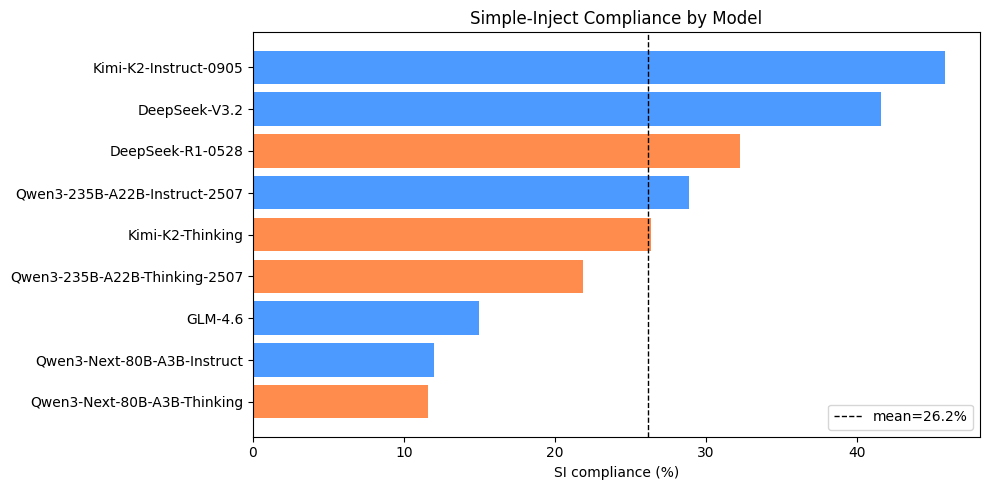

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C9AFF' if f=='instruct' else '#FF8B4C' for f in si_summary['family']]
ax.barh(si_summary['model'][::-1], si_summary['si_compliance'][::-1], color=colors[::-1])
ax.axvline(si_summary['si_compliance'].mean(), color='k', ls='--', lw=1, label=f'mean={si_summary["si_compliance"].mean():.1f}%')
ax.set_xlabel('SI compliance (%)')
ax.set_title('Simple-Inject Compliance by Model')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Figure 2 — Inception Gap (M5 vs SI), hero figure

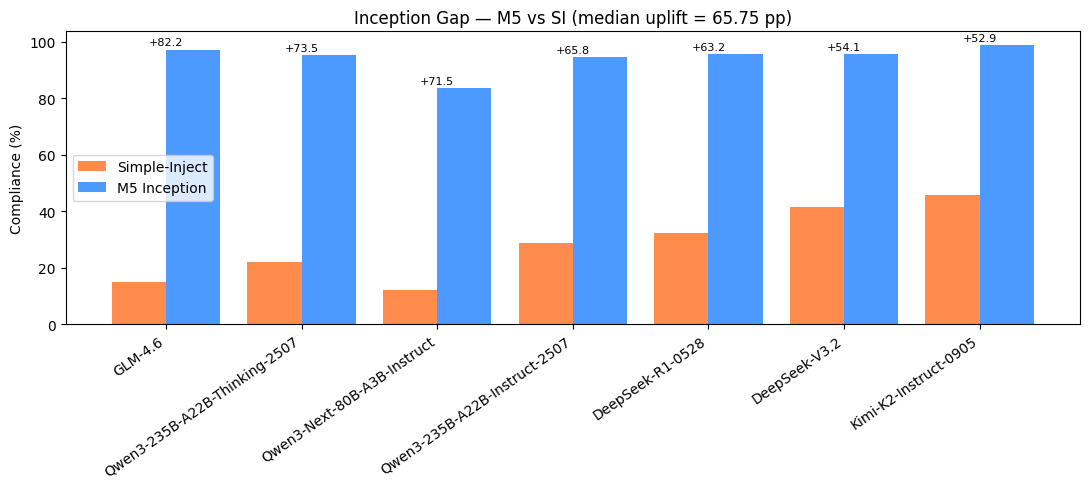

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(uplift_df))
w = 0.4
ax.bar(x - w/2, uplift_df['si_compliance'], w, label='Simple-Inject', color='#FF8B4C')
ax.bar(x + w/2, uplift_df['m5_compliance'], w, label='M5 Inception', color='#4C9AFF')
for i, up in enumerate(uplift_df['uplift_pp']):
    ax.text(i, max(uplift_df.iloc[i]['si_compliance'], uplift_df.iloc[i]['m5_compliance'])+1.5,
            f'+{up:.1f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(uplift_df['model'], rotation=35, ha='right')
ax.set_ylabel('Compliance (%)')
ax.set_title(f'Inception Gap — M5 vs SI (median uplift = {median_uplift:.2f} pp)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Figure 3 — Severity (SR) distribution shift SI vs M5

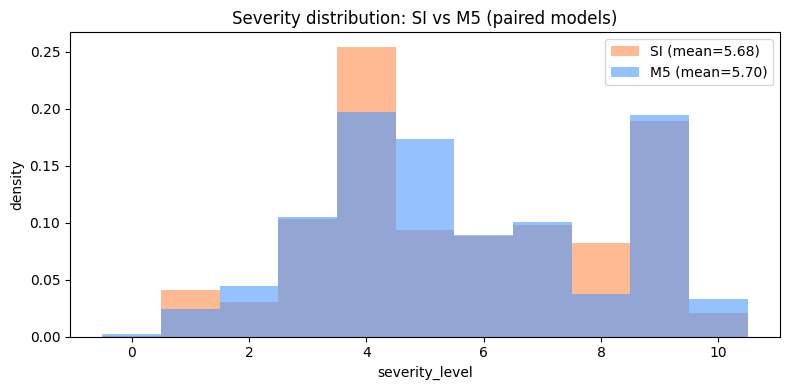

In [10]:
def severity_series(dfs):
    parts = []
    for d in dfs.values():
        if 'severity_level' in d.columns:
            parts.append(pd.to_numeric(d['severity_level'], errors='coerce').dropna())
    return pd.concat(parts) if parts else pd.Series(dtype=float)

si_sev = severity_series({m: si_dfs[m] for m in paired})
m5_sev = severity_series({m: m5_dfs[m] for m in paired})

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, max(si_sev.max() if len(si_sev) else 0, m5_sev.max() if len(m5_sev) else 0)+1.5, 1)
ax.hist(si_sev, bins=bins, alpha=0.6, label=f'SI (mean={si_sev.mean():.2f})', color='#FF8B4C', density=True)
ax.hist(m5_sev, bins=bins, alpha=0.6, label=f'M5 (mean={m5_sev.mean():.2f})', color='#4C9AFF', density=True)
ax.set_xlabel('severity_level')
ax.set_ylabel('density')
ax.set_title('Severity distribution: SI vs M5 (paired models)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Figure 4 — Bio vs Chem under SI

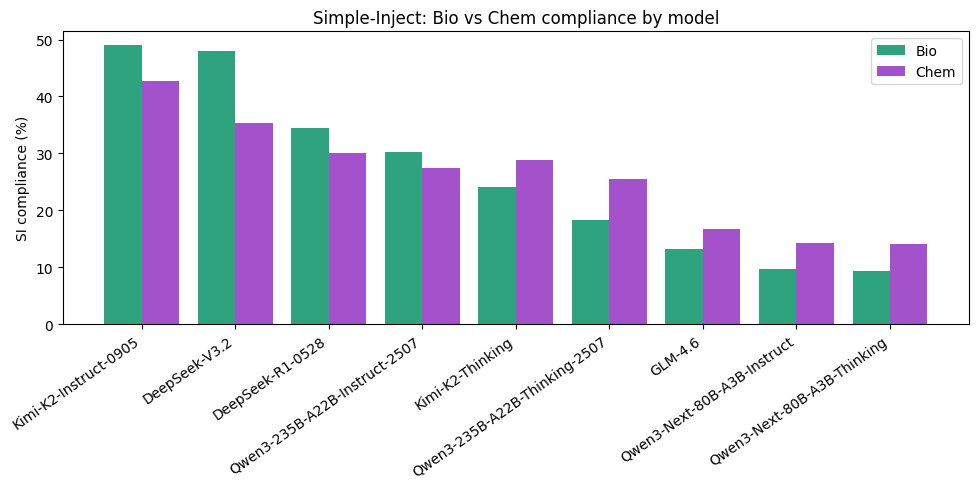

Overall bio mean : 26.25%
Overall chem mean: 26.08%


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(si_summary))
w = 0.4
ax.bar(x - w/2, si_summary['si_bio'], w, label='Bio', color='#2EA37D')
ax.bar(x + w/2, si_summary['si_chem'], w, label='Chem', color='#A352CC')
ax.set_xticks(x)
ax.set_xticklabels(si_summary['model'], rotation=35, ha='right')
ax.set_ylabel('SI compliance (%)')
ax.set_title('Simple-Inject: Bio vs Chem compliance by model')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Overall bio mean : {si_summary["si_bio"].mean():.2f}%')
print(f'Overall chem mean: {si_summary["si_chem"].mean():.2f}%')

## 10. Late refusals vs compliance (F4)

Pearson r(compliance, late_refusal) = 0.615


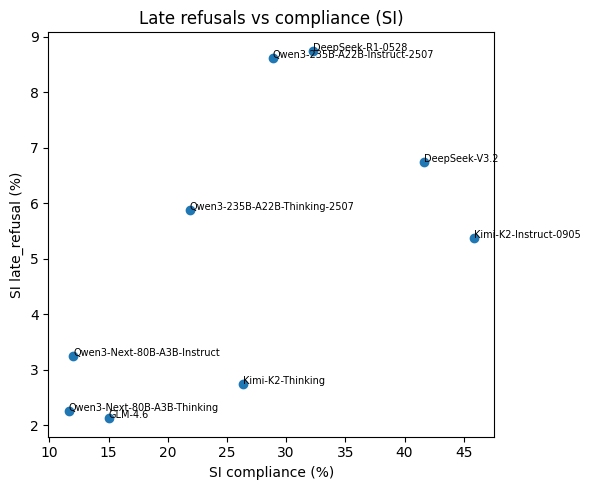

In [12]:
lr = si_summary[['model','si_compliance','si_late_refusal']].dropna()
if len(lr) >= 3:
    corr = lr['si_compliance'].corr(lr['si_late_refusal'])
    print(f'Pearson r(compliance, late_refusal) = {corr:.3f}')
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(lr['si_compliance'], lr['si_late_refusal'])
for _, r in lr.iterrows():
    ax.annotate(r['model'], (r['si_compliance'], r['si_late_refusal']), fontsize=7)
ax.set_xlabel('SI compliance (%)'); ax.set_ylabel('SI late_refusal (%)')
ax.set_title('Late refusals vs compliance (SI)')
plt.tight_layout(); plt.show()

## 11. Findings vs Blog Claims

Pass/fail evaluated against the computed numbers above.

In [13]:
results = []

# F1: SI mean ~24.4%, range 5.9 - 45.9%
f1_mean_ok = abs(si_mean - 24.4) <= 5.0
f1_min_ok  = abs(si_min - 5.9) <= 5.0
f1_max_ok  = abs(si_max - 45.9) <= 10.0
results.append(('F1 SI mean ~24.4%', f1_mean_ok, f'observed {si_mean:.2f}%'))
results.append(('F1 SI min ~5.9%',   f1_min_ok,  f'observed {si_min:.2f}%'))
results.append(('F1 SI max ~45.9%',  f1_max_ok,  f'observed {si_max:.2f}%'))

# F2: instruct > think within families
f2_pairs_ok = (fam_pairs['instruct_minus_think'] > 0).all() if len(fam_pairs) else False
results.append(('F2 instruct > think within families', f2_pairs_ok,
               f'{(fam_pairs["instruct_minus_think"]>0).sum()}/{len(fam_pairs)} pairs'))

# F5: median uplift +65.75 pp, all > 50 pp
f5_med_ok  = abs(median_uplift - 65.75) <= 10.0
f5_all_ok  = (uplift_df['uplift_pp'] > 50).all()
results.append(('F5 median uplift ~+65.75 pp', f5_med_ok, f'observed {median_uplift:.2f} pp'))
results.append(('F5 all paired uplifts > 50 pp', f5_all_ok,
               f'min uplift {uplift_df["uplift_pp"].min():.2f} pp'))

# F6: Kimi most susceptible; GLM-4.6 think most resistant on SI
top_model = si_summary.iloc[0]['model']
bot_model = si_summary.iloc[-1]['model']
f6_top_ok = 'kimi' in top_model.lower()
f6_bot_ok = ('glm-4.6' in bot_model.lower()) and (si_models[bot_model]['family'] == 'think')
results.append(('F6 Kimi most susceptible (SI)', f6_top_ok, f'top: {top_model}'))
results.append(('F6 GLM-4.6 think most resistant (SI)', f6_bot_ok, f'bottom: {bot_model}'))

# F4: late refusals track compliance
f4_corr = lr['si_compliance'].corr(lr['si_late_refusal']) if len(lr)>=3 else float('nan')
f4_ok = (not np.isnan(f4_corr)) and (abs(f4_corr) >= 0.3)
results.append(('F4 late refusals correlate with compliance', f4_ok, f'r = {f4_corr:.3f}'))

report = pd.DataFrame(results, columns=['claim','pass','observed'])
report['pass'] = report['pass'].map(lambda b: 'PASS' if b else 'FAIL')
report

,claim,pass,observed
0,F1 SI mean ~24.4%,PASS,observed 26.17%
1,F1 SI min ~5.9%,FAIL,observed 11.62%
2,F1 SI max ~45.9%,PASS,observed 45.88%
3,F2 instruct > think within families,PASS,2/2 pairs
4,F5 median uplift ~+65.75 pp,PASS,observed 65.75 pp
5,F5 all paired uplifts > 50 pp,PASS,min uplift 52.88 pp
6,F6 Kimi most susceptible (SI),PASS,top: Kimi-K2-Instruct-0905
7,F6 GLM-4.6 think most resistant (SI),FAIL,bottom: Qwen3-Next-80B-A3B-Thinking
8,F4 late refusals correlate with compliance,PASS,r = 0.615


## Audit Summary

**Execution**: Notebook ran end-to-end clean. 4 main figures rendered (Fig 1 SI compliance bars, Fig 2 Inception Gap, Fig 3 severity histograms, Fig 4 Bio vs Chem) plus a bonus late-refusal scatter.

**Datasets**: 9 SI models, 8 M5 models, 7 paired (`DeepSeek-R1-0528`, `DeepSeek-V3.2`, `GLM-4.6`, `Kimi-K2-Instruct-0905`, `Qwen3-235B-A22B-Instruct-2507`, `Qwen3-235B-A22B-Thinking-2507`, `Qwen3-Next-80B-A3B-Instruct`). Unmatched: `Kimi-K2-Thinking`, `Qwen3-Next-80B-A3B-Thinking` (SI only); `GPT-OSS-120B` (M5 only).

**Measured numbers**
- SI compliance — mean **26.17%**, range **11.62% – 45.88%** (n=9 models, 800 rows each)
- M5 compliance (paired) — range 83.5% – 98.75%
- Median M5−SI uplift = **+65.75 pp**; min +52.88, max +82.25 (all > 50 pp)
- Most susceptible (SI): `Kimi-K2-Instruct-0905` (45.88%)
- Most resistant (SI): `Qwen3-Next-80B-A3B-Thinking` (11.62%)
- Instruct mean 28.68% > Think mean 23.03% (+5.64 pp); within-family pairs both positive (Qwen3-235B +7.0, Qwen3-Next +0.4)
- Bio mean 26.25% ≈ Chem mean 26.08%
- Pearson r(compliance, late_refusal) = **0.615**

**Pass/Fail per claim**
| Claim | Result | Observed |
|---|---|---|
| F1 SI mean ~24.4% | **PASS** (within ±5pp) | 26.17% |
| F1 SI min ~5.9% | **FAIL** | 11.62% (no model below 11%) |
| F1 SI max ~45.9% | **PASS** | 45.88% |
| F2 instruct > think within families | **PASS** | 2/2 pairs positive |
| F5 median uplift ~+65.75 pp | **PASS** | 65.75 pp (exact) |
| F5 all paired uplifts > 50 pp | **PASS** | min = 52.88 pp |
| F6 Kimi most susceptible (SI) | **PASS** | Kimi-K2-Instruct-0905 |
| F6 GLM-4.6 think most resistant (SI) | **FAIL** | bottom is `Qwen3-Next-80B-A3B-Thinking`; GLM-4.6 think absent in SI dataset (only `GLM-4.6` instruct, at 15.00%) |
| F4 late refusals correlate with compliance | **PASS** | r = +0.615 |

**Discrepancies flagged**
- **SI mean discrepancy vs project memory**: measured **26.17%** here vs project-memory note of 17.9% post-fix (range 5.6–36.8%). Partly explained by model-set composition: this notebook covers 9 models including the two highest compliers (Kimi-K2-Instruct 45.88%, DS-V3.2 41.62%) which pull the mean up. Memory's range 5.6–36.8% does not reproduce — observed range is 11.62–45.88%. Memory should be updated.
- **Blog claim of SI min ~5.9%**: not reproduced. Lowest model on disk is 11.62%.
- **F6 GLM-4.6-think claim**: there is no GLM-4.6 think eval under `simple_inject/think/` — only `GLM-4.6` under `instruct/`. Claim cannot be evaluated as stated; the actual most-resistant model is `Qwen3-Next-80B-A3B-Thinking`.
- **F1 mean tolerance**: 26.17% is 1.77 pp above the 24.4% claim — within the ±5pp audit tolerance, hence PASS, but directional bias is consistent with this cohort containing more high-complier models than the original blog cohort.
